In [1]:
from Scripts import goncalves

# Introduction

@goncalves_parasite_2014 performed a unique experiment following a cohort of 882 children in an area of intense transmission from birth to 2-4 years of age in Tanzania. Surveillance was frequent and both active and passive. Parasitaemia was measured at all visits to the health clinic, regardless of whether symptoms were present or not. Clinical severity was recorded. This dataset, therefore, allowed @goncalves_parasite_2014 to determine the relationship between disease severity and parasitaemia.

For our purposes, this dataset allows us to:

- determine the numerical relationships between parasitaemia and the risks of clinical and severe malaria
- determine the numerical relationship between number of infections (exposure) and the risk of severe malaria

From these we can estimate many useful parameters for the vaccine model and its development:

- the risk of a first blood infection becoming clinical
- the risk a blood infection has detectable parasites ($>0$ parasites/μl) by microscopy
- the risk a blood infection becomes clinical with detectable parasites by microscopy
- the risk a blood infection becomes clinical with parasitaemia above any given threshold

In relation to RH5.1, which reduces parasitaemia at presentation, we can also use this dataset to estimate the reduction in risk of a clinical episode becoming severe.

Below we first show how we extract the relevant data from @goncalves_parasite_2014 (as unfortunately we did not have access to the raw dataset). Then we develop the mathematics to infer the relationships between parasitaemia and clinical and severe risks. Then we fit the derived equations to the data to estimate the relevant parameters for vaccine model. Finally we highlight some of the caveats to this analysis. 

# The @goncalves_parasite_2014 dataset

The key data which we will use is shown in @fig-goncalves_distributions, which is reproduced from Figure S2 of @goncalves_parasite_2014.


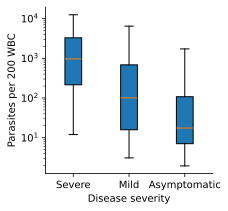

In [2]:
#| label: fig-goncalves_distributions
#| fig-cap: "Distributions of parasitaemias (parasites per 200 white blood cells (WBC)) in 3933 independent infections by clinical severity in 882 Tanzanian children aged 0 to 4 years old. Adapted from Figure S2 of @goncalves_parasite_2014 (moderately severe malaria and outliers are not plotted). Orange line: median; blue box: interquartile range; whiskers: 5^th^ and 95^th^-percentiles."

fig, ax = goncalves.figS2()


We assume that all mild and severe malaria episodes have fever and asymptomatic episodes do not have fever. We subsume the moderately severe episodes into the mild episodes. Additional data available from @goncalves_parasite_2014 for estimation are the following:

- Total child-years was 1762.8
- Number of children was 882
- Total severe malaria episodes was 122

@tbl-data tabulates the data that are available from @goncalves_parasite_2014 and that can be extracted from the box plots in Figure S2 of @goncalves_parasite_2014.

Severity | Range | Range of parasitaemia | No. of episodes | Error $^\dagger$
:--- | :---- | ----: | ---: | :--
all | detectable | $\ge1$ | 3933 | Poisson
asymptomatic | $\ge$ 95^th^ percentile | $\ge$ 1,830 | 60 | Poisson
asymptomatic | HDI $^\ast$ | $\ge$ 2,500 | 36 | Poisson
asymptomatic | $\ge$ max | $\ge$ 14,300 | 0 | Poisson
mild | HDI | $\ge$ 2,500 | 444 | Poisson
mild | $\ge$ max | $\ge$ 56,600 | 0 | Poisson
severe malaria | $<$ min | $<$ 3.7 | 0 | Multinomial
severe malaria | min - 5^th^ percentile |  3.7 - 12 | 6 | Multinomial
severe malaria | 5^th^ - 25^th^ percentiles |  12 - 215 | 24 | Multinomial
severe malaria | 25^th^ 50^th^ percentiles |  215 - 968 | 31 | Multinomial
severe malaria | 50^th^ 75^th^ percentiles |  968 - 3,280 | 30 | Multinomial
severe malaria | 75^th^ 95^th^ percentiles |  3,280 - 12,500 | 26 | Multinomial
severe malaria | 95^th^ - max |  12,500 - 25,400 | 5 | Multinomial
severe malaria | $\ge$ max |  $\ge$ 25,400 | 0 | Multinomial

: Data extracted from @goncalves_parasite_2014. $^\ast$ High density infection (HDI) defined as parasitaemia above 2,500 parasites per 200 WBC. $^\dagger$ Distribution type of the error structure. {#tbl-data}

Unfortunately we do not know the total numbers of mild and asymptomatic infections. The lower limit of detectable parasitaemia appears to be 1 parasite per 200 WBCs. We have no data on episodes below the detection limit with or without fever. We assume that there were no severe malaria episodes below the limit of detection otherwise they would have been reported.

The risk of severe malaria against cumulative number of infections (exposure) $n$, calculated by @goncalves_parasite_2014 is reproduced in @fig-severe_malaria_risk from Figure 2C of @goncalves_parasite_2014. We imputed their missing denominator values for $n$ = 9,11,12,13 by plotting log-denominator values against $n$, and we assumed the missing numerator values were zero.


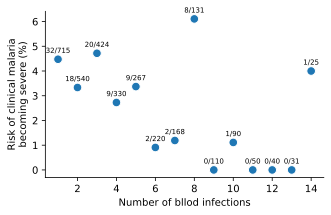

In [3]:
#| label: fig-severe_malaria_risk
#| fig-cap: "Risk of a severe malaria episode with the number of infections reproduced from @goncalves_parasite_2014. The numerator and denominator above each circle are the number of severe malaria episodes over the number of children with that number of infections, respectively. Adapted from Figure 2C of @goncalves_parasite_2014."

fig, ax = goncalves.fig2C()

To determine the numerical relationships between the risk of fever with parasitaemia and the risk of severe malaria with parasitaemia and exposure we need a model that estimates the rate of blood infection, the mean and standard deviation of the underlying distribution of parasitaemia and the probabilities of the three severity types.

# A model of the numerical relationship between parasitaemia and risks of clinical and severe malaria

## Infection rate and distributions of episodes by severity

The generating model of the @goncalves_parasite_2014 data is developed as follows. We assume that blood infections occur at a constant rate $\lambda$ (in units of blood infections per child per year). Let $b$ be the total number of child-years by the end of the study. Therefore, the total number of blood infections at the end of the study $T$, has a poisson distribution with parameter $b\lambda$:

$$T\sim\text{Poisson}(b\lambda)$$

We assume that blood infections with parasitaemias below 1 parasite per 200 WBC were undetectable. Therefore, not all $T$ blood infections are observed. Because of this, it follows that if we take a subset of blood infections with severity $i$, and their proportion of all blood infections $T$ is $\rho_i$, then their number at the end of the study, $Y_i$, is Poisson distributed with parameter $b\lambda\rho_i$:

$$Y_i\sim\text{Poisson}(b\lambda\rho_i)$$

This argument applies to asymptomatic and mild episodes, i.e., $i\in\{\text{asymptomatic, mild}\}$, because we do not know total episodes for these severity types. For severe malaria episodes however, for which we assume all were observed (i.e., 122), then the number of episodes within given ranges of parasitaemias ([@tbl-data]), are multinomially distributed with a vector of probabilities $\boldsymbol{\rho_\text{severe}}$:

$$\boldsymbol{Y_\text{severe}} \sim \text{Multinomial}(\boldsymbol{\rho_\text{severe}})$$

where the sum of the elements of $\boldsymbol{Y_\text{severe}}$ is 122 episodes and the sum of the elements of $\boldsymbol{\rho_\text{severe}}$ is 1.

Our aim is to develop a mathematical model that allows us to calculate $\rho$ for each severity type in [@tbl-data].

## Distribution of the cumulative number of blood infections over all blood infections

Given that the risk of severe malaria is related to the cumulative number of blood infections, we require the distribution of the cumulative number of blood infections over all blood infections. That is, given a randomly chosen infection from the set of all blood infections, what is the probability it is the $N^\text{th}$ infection in the child whose infection it is. 

Let there be $c$ children in the cohort and let $\lambda$ be their constant infection rate. Then the cumulative number of blood infections experienced by child $i$ after time $\overline{t}$, $Y_i$, is poisson distributed 

$$Y_i\sim\text{Poi}(\lambda \overline{t})$$

The total number of blood infections across all children is $M=\sum_{i=1}^{c} Y_i$. 

Let $N$ be infection order, i.e, $N=1$ is a child's first infection, $N=2$ is a child's second infection, and so on.

Let $p(n)$ be the probability that an infection chosen at random from the set of $M$ blood infections is an $N^\text{th}$ infection. The probability mass function can be derived as follows 

$$
p(n|\lambda\overline{t}) = \text{Pr}(N=n) = \frac{\sum_{i=1}^{c} I(Y_i\ge n)}{M} \tag{1}
$$ {#eq-eq1}

where $I(\cdot)$ is the indicator function (1 if $Y_i\ge n$, 0 otherwise).

We have not been able to find a closed form solution to this equation. We therefore resort to simulation to examine how sensitive it is to the infection rate $\lambda$. We assume $\overline{t}$ is fixed and given by the number of child years divided by the number of children, i.e., $\overline{t} = 1762.8/882 = 2.0$. We vary $\lambda$ from 2 to 3 blood infections per year. For each value of $\lambda$ we simulate blood infections in 882 children over 2 years and calculate $p(n|\lambda\overline{t})$ using [@eq-eq1] for all $n$. We do this 100 times for each value of $\lambda$ to determine the mean and variation. The code is in [Scripts/goncalves.py](Scripts/goncalves.py). The results are shown in [@fig-pn_dist]. 

For a fixed $\lambda$ and $n$ there is little variation in $p(n|\lambda\overline{t})$ for 882 children as shown by the ±2SD error bands ([@fig-pn_dist]). The PMF does vary with $\lambda$, and more so for the first two blood infections. 

When fitting the @goncalves_parasite_2014 data, we use a lookup table for values of $p(n|\lambda\overline{t})$, with $\lambda$ stratified as in [@fig-pn_dist]. Fortunately, as we will see below, the estimate of $\lambda$ from the fit of data is quite precise (~1% error) so this will not introduce much error in our other parameter estimates.

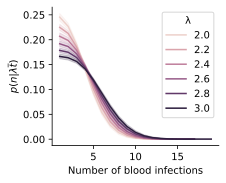

In [4]:
#| label: fig-pn_dist
#| fig-cap: "Probability mass function (PMF) for the cumulative number of blood infections $p(n|\\lambda\\overline{t})$ in a cohort of 882 children followed for two years for different blood infection rates. Bands represent ±2SD around the mean PMF estimated from 100 simulations."

fig, ax, df = goncalves.simulate_p_n()

## Distributions of underlying and observed parasitaemias

Based on the data in Figure S1 of @goncalves_parasite_2014, we initially modelled log-parasitaemia $X$, as a continuous random variable normally distributed with mean $\mu$ and standard deviation $\sigma$. Although the assumption of normality resulted in good fits to the data (not shown), the normal distribution's long tails predicted too many blood infections with parasitaemias above 10^5^ parasites per 200 WBC. Instead we use the raised cosine distribution which has thinner tails than the normal distribution:

$$X \sim \text{Raised cosine}(\mu, s)$$

Let $p(x)$ be the probability density function of $X$, which has the form

$$p(x) = \frac{1}{2s}\left[1+\cos\left(\frac{x-\mu}{s}\pi\right)\right]$$

We note from Figure S5 of @goncalves_parasite_2014 that mean detectable parasitaemia after the first few months of life is about 100 parasites per 200 WBC and remains almost constant for the next three years. For model fitting we assume it remains constant at this value.

Only parasitaemias above 1 parasite per 200 WBC were detectable, therefore the distribution of *observed* parasitaemia is a Raised cosine distribution truncated at $x=0$. This has a mean $\mu^\prime$ equal to $\frac{1}{4s}[\mu+s]^2 - \frac{s}{2\pi^2}\left[1 + \cos\left(-\frac{\mu}{s}\pi\right) \right]$. When model fitting, we compute $\mu$, assuming $\mu^\prime = \log_{10}100 = 2$, using the Newton root-finding method of Stan.

## A model of the risk of fever

We note from @fig-goncalves_distributions that asymptomatic blood infections (i.e., those without fever) have on average lower parasitaemias than symptomatic blood infections. In other words, the risk of fever increases with parasitaemia. Immunity to fever develops slowly with cumulative exposure, therefore over a long timescale the risk of fever declines with exposure. However, we can ignore this decline because of the short timescale of the Goncalves study. Therefore, the risk of fever increases with parasitaemia $x$, and is independent of cumulative exposure $n$. We chose to model the relationship of risk of fever with log-parasitaemia with a logistic curve that rises from 0 at low parasitaemia to 1 at high parasitaemia ([@fig-risk_fever_with_parasitaemia]):


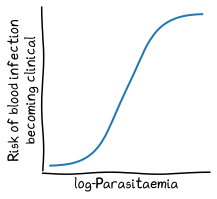

In [5]:
#| label: fig-risk_fever_with_parasitaemia
#| fig-cap: "Schematic of the model of the risk of fever with log-parasitaemia."

fig, ax = goncalves.risk_fever_with_parasitaemia()

$$\text{Pr}(\text{fever}|x) = \frac{1}{1+\exp(-a_\text{F}[x-c_\text{F}])}$$

where $a_\text{F}$ is the speed at which the curve increases with log-parasitaemia and $c_\text{F}$ is log-parasitaemia at half-maximum.

# A model of the risk of severe malaria

[@fig-goncalves_distributions] demonstrates that the risk of severe malaria increases with parasitaemia. In addition we see from [@fig-severe_malaria_risk] that the risk of severe malaria declines with cumulative number of blood infections as immunity develops. As with fever, we chose to model the relationship between risk of severe malaria and parasitaemia with logistic curves that rise from 0 at low parasitaemia and plateau at high parasitaemia ([@fig-risk_severe_with_parasitaemia]). 


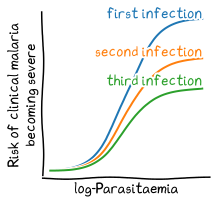

In [6]:
#| label: fig-risk_severe_with_parasitaemia
#| fig-cap: "Schematic of the model of the risk of severe malaria with log-parasitaemia and cumulative number of blood infections."

fig, ax = goncalves.risk_severe_with_parasitaemia()

An exponentially decaying curve has been shown to fit the relationship between risk of severe malaria and cumulative number of blood infections [@munoz_sandoval_plasmodium_2025]. 

The joint probability of severe malaria given fever, parasitaemia $x$ and cumulative blood infections $n$ can be modelled with the following equation:

$$\text{Pr}(\text{severe}|\text{fever},n,x) = \frac{b_\text{S}\exp(-d_\text{S}[n-1])}{1+\exp(-a_\text{S}[x-c_\text{S}])}$$

where $a_\text{S}$ is the speed at which the curve increases and $c_\text{S}$ is log-parasitaemia at half-maximum. The parameter $d_\text{S}$ is the rate of decline in risk with cumulative number of blood infections and $b_\text{S}$ is the theoretical maximum risk of a first infection as parasitaemia tends to infinity.

It will be useful for later to marginalise out fever and $n$. First fever:

$$\text{Pr}(\text{severe}|n,x) = \text{Pr}(\text{severe}|\text{fever}, n,x)\text{Pr}(\text{fever}|n,x) + \text{Pr}(\text{severe}|\overline{\text{fever}}, n,x)\text{Pr}(\overline{\text{fever}}|n,x)$$

However a child cannot have severe malaria without fever, i.e., $\text{Pr}(\text{severe}|\overline{\text{fever}}, n,x)=0$. Moreover, as we are assuming that $n$ is independent of fever, i.e., $p(\text{fever}|n,x) = p(\text{fever}|x)$, therefore

$$\text{Pr}(\text{severe}|n,x) = \text{Pr}(\text{severe}|\text{fever}, n,x) \text{Pr}(\text{fever}|x)$$

And now marginalise out $n$. We first write

$$\text{Pr}(\text{severe}|x) = \text{Pr}(\text{severe}|\text{fever}, x) \text{Pr}(\text{fever}|x)$$

where

$$
\begin{align*}
\text{Pr}(\text{severe}|\text{fever}, x) &= \sum_{n=1}^{\infty} \text{Pr}(\text{severe}|\text{fever},n,x)p(n|\lambda\overline{t}) \\
               &= \sum_{n=1}^{\infty} \frac{b_\text{S}\exp(-d_\text{S}[n-1])}{1+\exp(-a_\text{S}[x-c_\text{S}])}p(n|\lambda\overline{t}) \\
               &= \frac{b_\text{S}}{1+\exp(-a_\text{S}[x-c_\text{S}])} \sum_{n=1}^{\infty} \exp(-d_\text{S}[n-1]) p(n|\lambda\overline{t}) \\
               &= \frac{b_\text{S}}{1+\exp(-a_\text{S}[x-c_\text{S}])} F(d_\text{S}, \lambda\overline{t}) 
\end{align*}
$$

where $F(d_\text{S}, \lambda\overline{t})=\sum_{n=1}^{\infty} \exp(-d_\text{S}[n-1]) p(n|\lambda\overline{t})$ has to be solved numerically as $p(n|\lambda\overline{t})$ has no closed form.

## Joint probabilities of severity type with parasitaemia

The probability density of parasitaemia $x$ of all episodes is

$$p(\text{all}, x) = p(x)$$

The probability density of parasitaemia $x$ joint with fever is

$$p(\text{fever}, x) = \text{Pr}(\text{fever}|x) p(x)$$

Therefore the probability density of parasitaemia $x$ joint with no fever (i.e., asymptomatic) is

$$
\begin{align*}
p(\text{asymptomatic}, x) &= \text{Pr}(\overline{\text{fever}}|x)p(x) \\
&= [1 - \text{Pr}(\text{fever}|x)] p(x) \\
&= p(x) - \text{Pr}(\text{fever}|x) p(x) \\
&= p(x) - p(\text{fever},x)
\end{align*}
$$

The probability density of parasitaemia $x$ joint with severe malaria is

$$
\begin{align*}
p(\text{severe}, x) &= \text{Pr}(\text{severe}|x)p(x)\\
                &= \text{Pr}(\text{severe}|\text{fever},x)\text{Pr}(\text{fever}|x)p(x) \\                 
                &= \text{Pr}(\text{severe}|\text{fever},x)p(\text{fever},x)
\end{align*}
$$

The probability density of parasitaemia $x$ joint with mild severity is the probability density of parasitaemia $x$ joint with fever minus the probability density of parasitaemia $x$ joint with severe malaria:

$$p(\text{mild}, x) = p(\text{fever}, x) - p(\text{severe}, x)$$

## Disease severity cumulative probabilities 

The above joint probabilities are then used to obtain probabilities of the specific disease severity types and parasitaemia ranges in [@tbl-data]. The probability $\rho_{C,x}$, of severity type $C\in\{\text{all, asymptomatic, mild, severe}\}$ occurring above parasitaemia $x$ is given by the complementary cumulative density function

$$\rho_{C,x} = \text{Pr}(C, X\ge x) = \int_{x}^{\infty}p(C,x)\,dx$$

These integrals are solved numerically in Stan using the `integrate_1d()` function.

For severe malaria we will require the probability of log-parasitaemia between $x_1$ and $x_2$:  

$$\text{Pr}(x_1\le X < x_2|\text{severe}) = \frac{\text{Pr}(\text{severe}, x_1\le X < x_2)}
{\text{Pr}(\text{severe})} = \frac{\rho_{\text{severe},x_1}-\rho_{\text{severe},x_2}}{\rho_{\text{severe},-\infty}}$$

for all pairs of log-parasitaemias $x_1$, $x_2$ in [@tbl-data].

## Declining risk of severe malaria with number of infections

To estimate the declining risk of severe malaria with number of infections, we need the probabilities of severe malaria given the number of infections $n$ and detectable parasites (i.e., $X\ge0$):

$$\text{Pr}(\text{severe}|n, X\ge0) = \frac{\text{Pr}(\text{severe}, X\ge 0|n)}{\text{Pr}(X\ge 0)}$$

The denominator $\text{Pr}(X\ge 0) = \int_0^\infty p(x)\,dx$.

The numerator is found as follows. First we apply the rule of total probability to include parasitaemia $x$:

$$\text{Pr}(\text{severe}, X\ge 0|n) = \int_0^\infty \text{Pr}(\text{severe}|n, x) p(x|n)\,dx$$

As $n$ is independent of any $x$, $p(x|n) = p(x)$. Next we apply the rule of total probability to include fever, noting, as before, that severe malaria can only occur with fever:

$$
\begin{align*}
\text{Pr}(\text{severe}, X\ge 0|n) &= \int_0^\infty \text{Pr}(\text{severe}|\text{fever}, n, x) \text{Pr}(\text{fever}|x) p(x)\,dx \\
                               &= \int_0^\infty \text{Pr}(\text{severe}|\text{fever}, n, x) p(\text{fever}, x)\,dx
\end{align*}
$$

This integral is solved numerically in Stan using the `integrate_1d()` function.

## Estimated risk of a blood infection becoming clinical

The probability of a blood infection becoming clinical is

$$\text{Pr}(\text{fever}) = \int_{-\infty}^{\infty} \text{Pr}(\text{fever}|x) p(x)\,dx$$

# Model fit and analysis

We fit the model to the data using Hamilton Monte Carlo (HMC) using Stan version 2.3. The code is in [Data_Fitting/Goncalves/goncalves1.stan](../Data_Fitting/Goncalves/goncalves1.stan) and the fit diagnostics in [Data_Fitting/Goncalves/goncalves1.ipynb](../Data_Fitting/Goncalves/goncalves1.ipynb).

We estimate the parameters $\lambda$, $\sigma$, $a_\text{F}$, $c_\text{F}$, $a_\text{S}$, $c_\text{S}$, $b_\text{S}$ and $d_\text{S}$. We fix $\mu^\prime=2$ as this allows HMC convergence to the posterior. This can be justified by noting there is little uncertainty in its value as demonstrated in Figure S5 of @goncalves_parasite_2014.

## Priors

### Blood blood infection rate, $\lambda$

@goncalves_parasite_2014 report 3933 independent blood infections over 1762.8 child-years at risk. Which is 2.2 observed blood infections per child per year. Some blood infections may not have been observed which introduces uncertainty in blood infection rate. We therefore take an informative Gamma prior with shape 4 and scale 2 which has mean 2 and and standard deviation 1. 

### Variation in log-parasitaemia, $s$

Observed parasitaemia varies from 1 to 10^5^ parasites per 200 WBC, which is 0 to 5 on a log scale. The standard deviation of the Raised cosine distribution is approximately 0.36s. If 0-5 covers approximately six standard deviations then $s$ is approximately $\frac{5}{6\times 0.36} = 2.3$. We take an informative Gamma prior with shape 16 and scale 8 which has mean 2 and standard deviation 0.5. 

### Parasitaemia at half-maximum-risk of fever, $c_F$

Given that fever occurs across the full range of parasitaemias (@fig-goncalves_distributions) $c_F$ is likely to be less than zero. We have no other data to fix a prior, we therefore take a broad normal prior with mean -1 and standard deviation 0.5.

### Rate of increase of risk of fever with parasitaemia, $a_F$

As we have no data to determine a prior on $a_F$ we take a broad truncated normal prior with mean 1 and standard deviation 1.

### Parasitaemia at half-maximum-risk of severe malaria, $c_S$ 

The median parasitaemia for severe malaria is around 1,000 parasites per 200 WBC (@fig-goncalves_distributions). It is not clear whether $c_S$ is a useful predictor of this median. We therefore take a truncated normal with mean 3 for $c_S$, but make it broad with a standard deviation of 0.5.

### Rate of increase of risk of severe malaria with parasitaemia, $a_S$ 

As we have no data to determine a prior on $a_F$ we take a broad truncated normal prior with mean 1 and standard deviation 1.

### Maximum risk of severe malaria on first blood infection, $b_S$ 

@munoz_sandoval_plasmodium_2025 estimated the risk of severe malaria on first blood infection as 4.5% $\pm$ 0.6%. This is an average over the distribution of parasitaemias on first blood infection. So $b_S$ is not equivalent and should be higher than this value.  We therefore take a broad truncated normal prior with mean 0.1 and standard deviation 0.1.

### Rate of decline of risk of severe malaria with number of blood infections, $d_S$

@munoz_sandoval_plasmodium_2025 estimated $d_S$ to be 0.12 $\pm$ 0.04. We therefore use a truncated normal prior with mean 0.12 and standard deviation 0.04 for $d_S$.

## Estimated risks and fits to data

The estimated risks of fever and severe malaria with parasitaemia and the fits of the model to the data are shown in [@fig-model_fits].

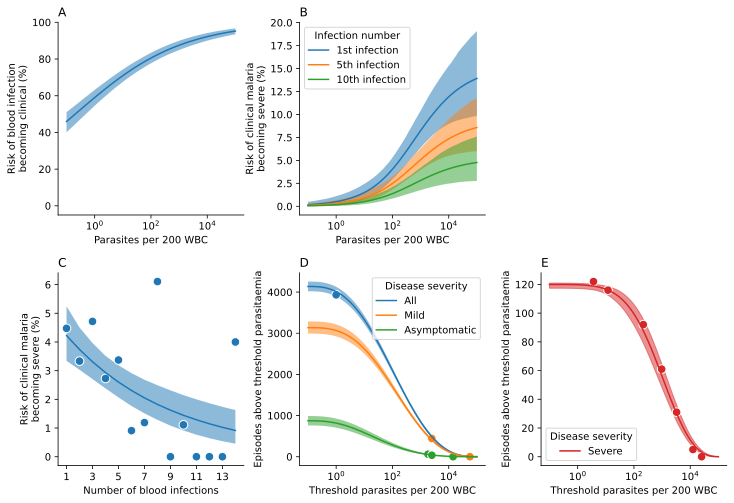

In [7]:
#| label: fig-model_fits
#| fig-cap: "Model predictions (top row) and fits to data (bottom row). A) Predicted risk of a blood infection becoming clinical with parasitaemia. B) Predicted risk of clinical malaria becoming severe with parasitaemia for the 1^st^, 5^th^ and 10^th^ blood infections. C) Fit of risk of a clinical episode becoming severe with cumulative number of blood infections. Circles are the rates from @fig-severe_malaria_risk. D) Fit of all, mild and asymptomatic episodes above threshold parasitaemia. Circles are data from @tbl-data. E) Fit of severe malaria episodes above threshold parasitaemia. Circles are from @tbl-data. In all panels, lines are posterior mean estimates and bands are 95% credible intervals."

fig, axs = goncalves.risk_estimates('../Data_Fitting/Goncalves/goncalves1_draws.csv')

The estimated risk of a blood infection becoming clinical increases from about 45% at 1 parasite per 200 WBC to above 90% at over 10^5% parasites per 200 WBC ([@fig-model_fits]A). This compares favourably to estimates in Figure 5A (purple crosses) of @henry_infection_2022.

The estimated risk of a clinical episode becoming severe is negligible at low parasitaemias then steadily rises at a rate dependent on the number of blood infections a person has experienced ([@fig-model_fits]B). On a first infection, the risk is roughly 15% at 10^5^ parasites per 200 WBC, dropping to about 5% on the tenth infection. 

The fits to the data in [@fig-model_fits]C-E are all excellent with little uncertainty.

The predicted distributions of parasitaemia for disease severity types are shown in [@fig-predicted_distributions]A, and a comparison between the observed (blue) and predicted (white) distributions, represented as boxplots are shown in [@fig-predicted_distributions]B.

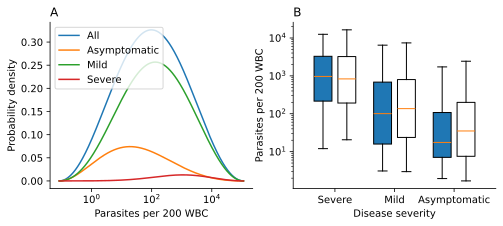

In [8]:
#| label: fig-predicted_distributions
#| fig-cap: "Distributions of parasitaemia for different severities. (A) Probability densities for parasitaemia in all severity types. (B) Box plots of parasitaemia for severe, mild and asymptomatic severity types. Blue: data from @goncalves_parasite_2014, white: model predictions."

fig, axs = goncalves.distributions('../Data_Fitting/Goncalves/goncalves1_draws.csv')

In [9]:
#| output: false
p = goncalves.get_estimates('../Data_Fitting/Goncalves/goncalves1_draws.csv')

Overall, fits to the data look good, suggesting our models of the distribution of parasitaemia and the risks of fever and severe malaria are reasonable.

## Parameter estimates

The estimated parameters are given in [@tbl-est].

Parameter | Estimate
:-- | :-:
$\lambda$ | `{python} f'{p.λ.mean():.2f}'` $\pm$ `{python} f'{p.λ.std():.2f}'`
$\mu$ | `{python} f'{p.μ.mean():.3f}'` $\pm$ `{python} f'{p.μ.std():.3f}'`
$s$ | `{python} f'{p.σ.mean():.2f}'` $\pm$ `{python} f'{p.σ.std():.2f}'`
$a_F$ | `{python} f'{p.aF.mean():.2f}'` $\pm$ `{python} f'{p.aF.std():.2f}'` 
$c_F$ | `{python} f'{p.cF.mean():.2f}'` $\pm$ `{python} f'{p.cF.std():.2f}'` 
$a_S$ | `{python} f'{p.aS.mean():.1f}'` $\pm$ `{python} f'{p.aS.std():.1f}'` 
$c_S$ | `{python} f'{p.cS.mean():.1f}'` $\pm$ `{python} f'{p.cS.std():.1f}'` 
$b_S$ | `{python} f'{p.bS.mean():.2f}'` $\pm$ `{python} f'{p.bS.std():.2f}'` 
$d_S$ | `{python} f'{p.dS.mean():.2f}'` $\pm$ `{python} f'{p.dS.std():.2f}'` 

: Estimated parameters (mean $\pm$ SEM). {#tbl-est}

And derived parameters used in the vaccine model and for model development are given in [@tbl-derived].

Description | Estimate
:------- | :-:
Probability a blood infection becomes clinical | `{python} f'{p.P_fever.mean():.3f}'` $\pm$ `{python} f'{p.P_fever.std():.3f}'`
Probability a blood infection has $\ge$ 1 parasite per 200 WBC | `{python} f'{p.P_detect.mean():.3f}'` $\pm$ `{python} f'{p.P_detect.std():.3f}'`
Probability a blood infection has $\ge$ 1 parasite per 200 WBC and becomes clinical | `{python} f'{p.P_fever_and_detect.mean():.3f}'` $\pm$ `{python} f'{p.P_fever_and_detect.std():.3f}'`
Probability a blood infection has >5000 parasites/μl and becomes clinical | `{python} f'{p.P_fever_and_5000.mean():.3f}'` $\pm$ `{python} f'{p.P_fever_and_5000.std():.3f}'`
Probability a clinical episode on first infection becomes severe, $\rho_\text{severe}$ | `{python} f'{p.P_severe.mean():.3f}'` $\pm$ `{python} f'{p.P_severe.std():.3f}'`
Rate of decline of risk of severe malaria with number of infections, $\delta_\text{severe}$ ($d_S$) | `{python} f'{p.dS.mean():.2f}'` $\pm$ `{python} f'{p.dS.std():.2f}'`

: Derived parameters used in the model and for model development (mean $\pm$ SEM). {#tbl-derived}

We conclude that the relationship between the risk of a blood infection becoming clinical with log-parasitaemia $x$ is

$$\text{Pr}(\text{fever}|x) = \frac{1}{1+\exp(-`{python} round(p.aF.mean(), 2)`[x+`{python} round(-p.cF.mean(), 2)`])}$$

And the relationship between the risk of severe malaria with log-parasitaemia $x$, given fever on the *n*^th^ infection is

$$\text{Pr}(\text{severe}|\text{fever},n,x) = \frac{`{python} round(p.bS.mean(), 2)` \exp(-`{python} round(p.dS.mean(), 2)`[n-1]) }{1+\exp(-`{python} round(p.aS.mean(), 1)`[x-`{python} round(p.cS.mean(), 1)`])}$$

@goncalves_parasite_2014 record parasites per 200 white blood cells. There are roughly 10,000 WBCs per $\mu\text{l}$. So a conversion factor of 50 is required to convert to parasites per $\mu\text{l}$. Under this change of scale, $c_\text{F}$ and $c_\text{S}$ increase by $\log_{10}50=1.7$.

# Caveats

1. We assume all children are equally susceptible and experience the same force of infection.
2. Distribution of parasitaemia is symmetrical about the mean. But there may be a fatter tail for undetectable episodes.
3. All blood infections are independent blood infections. Recrudescences are not counted as independent blood infection. Clinical episodes were actively detected and treated with amodiaquine. However, amodiaquine was known to have a failure rate of over 75% in Tanzania in 2005. Therefore recrudescences were highly likely. @goncalves_parasite_2014 mitigated against this by only categorising a blood infection as independent if it occurred more than four weeks after the last detected blood infection. But with such a high failure rate this assumption may lead to an over-estimate of the number of true independent blood infections. This would lead to an underestimate of the decay in the risk of severe malaria. We examine sensitivity to changes in this, and other, parameters in [Notebook S10](S10_sensitivity_analysis.ipynb).

::: {#refs}
:::